# Three-Pathway Viscosity & Rheology Characterization

This notebook applies the **APP_V6 live characterization stack** to experimental cone-plate runs
(PEG, Carbopol, Sepineo, Solagum, Silicone, TIMS) and compares predictions against manual label
truth and Brookfield reference data where available.

## Experimental units & replicates

APP_V3 CSVs often reuse **cell indices** across unrelated fills. Each run is therefore keyed by
`(Cell_Label, cell)`, not `cell` alone. Many labels are **replicates** (same sample measured
on several cells); where $N\ge 2$ we report both **per-replicate** and **mean** prediction /
`|%err|`.

Silicone oils are Newtonian. Almost every silicone `(label, cell)` is a single-RPM amplitude
measurement; if a few RPMs appear in one group they are still forced through the **Newtonian**
path (per-RPM single-speed fits), not multi-RPM stress routing.

Unlabeled polymer runs are skipped entirely. For labeled polymer runs such as `10%300K_7158`,
the suffix encodes the manually measured viscosity at 50% torque and is used as the **primary**
truth for parity and accuracy. Exact-RPM Brookfield values are retained **alongside** that manual
truth as a secondary comparison whenever the RPM exists in the master database.

## Characterization pathways

After each multi-RPM cell is fitted, shear stress at the hitpoint (deepest retained gap after
pretrim) is used to fit $\tau = K_{\mathrm{stress}}\,\dot\gamma^{n_{\mathrm{stress}}}$.
Routing then uses $n_{\mathrm{stress}}$:

| Band | Pathway | Viscosity logic |
|------|---------|-----------------|
| single RPM, or $0.9 \le n \le 1.1$ | **Newtonian** | linear amplitude: $\mu = A / K$ ($p=1$) |
| $0.5 \le n < 0.9$ | **Mild shear-thinning** | mix: $n_{\mathrm{stress}}$ shape + linear-amplitude magnitude at $\dot\gamma_{\min}$ |
| $n < 0.5$ | **Strong shear-thinning** | direct torque: $\mu = \tau_{\mathrm{hit}} / \dot\gamma$ |
| $n > 1.1$ | **Shear-thickening** | amplitude power-law |

Package constants (frozen — **not** re-fit here): `SILICONE_K = 3e-4`, `SILICONE_P = 1.0`,
`H_C_UNIVERSAL_MM`, regime bands in `viscometry.rheology.constants`.

## Ground truth
- Polymer Brookfield table: `notebooks/data/three_pathway/master_viscosity.csv`
- Polymer runs are only kept when the label includes a manual viscosity suffix
  (for example `10%300K_7158`, `1%sep_2148`).
- For labeled polymers, the suffix value is the **primary** truth for parity and `|%err|`.
- Polymer Brookfield `%err` is also computed when the experimental RPM is an **exact** tabulated
  speed in the master mapping (no nearest-RPM pairing).
- Silicone: viscosity from label after `a` (`…_a11860` → 11860 cP). Short grades
  (`l60…_a69.08`, `l5_b_5.865`) store Pa·s and are converted ×1000 → cP.
- TIMS / unmatched labels: predict + shear plots only (no `%err`)
- Figures are shown **inline** in this notebook (not written into the repo)


In [1]:
# §2 Setup
from __future__ import annotations

import io
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
# allow running from notebooks/runs or repo root
for candidate in [NOTEBOOK_DIR, NOTEBOOK_DIR.parent, NOTEBOOK_DIR.parent.parent]:
    if (candidate / "src" / "viscometry").is_dir():
        ROOT = candidate
        break
else:
    ROOT = NOTEBOOK_DIR.parents[1]

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from viscometry.rheology.live_adapter import predict_cell_rheology
from viscometry.rheology.constants import (
    FIT_R2_MIN,
    H_C_UNIVERSAL_MM,
    NEWTONIAN_N_HIGH,
    NEWTONIAN_N_LOW,
    PCT_TO_PA,
    SILICONE_K,
    SILICONE_P,
    STRONG_THINNING_N_MAX,
    shear_rate,
)

DATA = ROOT / "notebooks" / "data" / "three_pathway"
OUT_DIR = DATA / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FAMILY_FILES = {
    "PEG": "PEG.csv",
    "Carbopol980": "carbopol.csv",
    "Sepineo": "sepineo.csv",
    "Solagum": "solagum.csv",
    "Silicone": "silicone.csv",
    "TIMS": "TIMS.csv",
}
FAMILY_COLOR = {
    "PEG": "#1f77b4",
    "Carbopol980": "#d62728",
    "Sepineo": "#2ca02c",
    "Solagum": "#ff7f0e",
    "Silicone": "#9467bd",
    "TIMS": "#8c564b",
}
# Exact RPM match only (master mapping speeds); no nearest-neighbor pairing.
RPM_MATCH_TOL = 1e-6
NON_NEWTONIAN = {"mild_shear_thinning", "strong_shear_thinning", "shear_thickening"}

print("ROOT =", ROOT)
print("DATA =", DATA)
print(f"SILICONE_K={SILICONE_K:.3e}  SILICONE_P={SILICONE_P}  hc={H_C_UNIVERSAL_MM}")
print(f"N bands: Newtonian [{NEWTONIAN_N_LOW}, {NEWTONIAN_N_HIGH}], strong < {STRONG_THINNING_N_MAX}")
print(f"Polymer RPM truth match: exact (±{RPM_MATCH_TOL:g})")


ROOT = /Users/ianng/Documents/GitHub/Automated_Viscometry
DATA = /Users/ianng/Documents/GitHub/Automated_Viscometry/notebooks/data/three_pathway
SILICONE_K=3.000e-04  SILICONE_P=1.0  hc=0.2774
N bands: Newtonian [0.9, 1.1], strong < 0.5
Polymer RPM truth match: exact (±1e-06)


## §3 Master viscosity database

Brookfield reference viscosities at listed RPMs for Carbopol980, PEG, Sepineo, and Solagum.
Lookup requires family (+ MW for PEG), concentration, and an **exact** tabulated RPM
(no nearest-speed pairing of untested experimental RPMs).

These values are carried as a **secondary** comparison for labeled polymer runs; the manual
label suffix remains the primary truth in this notebook.



In [2]:
# §3 Load master viscosity DB
master = pd.read_csv(DATA / "master_viscosity.csv")
master["Polymer"] = master["Polymer"].astype(str).str.strip()
master["MW"] = master["MW"].astype(str).str.strip().str.upper().replace({"NAN": np.nan, "": np.nan})
master["Concentration_%wt"] = pd.to_numeric(master["Concentration_%wt"], errors="coerce")
master["speed_RPM"] = pd.to_numeric(master["speed_RPM"], errors="coerce")
master["Viscosity_cP"] = pd.to_numeric(master["Viscosity_cP"], errors="coerce")
master = master.dropna(subset=["Polymer", "Concentration_%wt", "speed_RPM", "Viscosity_cP"])

def lookup_mu_true(family: str, conc, rpm, mw=None, tol: float = RPM_MATCH_TOL):
    """Return Brookfield Viscosity_cP only when rpm is an exact tabulated speed, else None."""
    if family is None or conc is None or rpm is None:
        return None
    if family in ("Silicone", "TIMS"):
        return None
    sub = master[master["Polymer"] == family]
    if family == "PEG":
        if mw is None or (isinstance(mw, float) and not np.isfinite(mw)):
            return None
        sub = sub[sub["MW"] == str(mw).upper()]
    sub = sub[np.isclose(sub["Concentration_%wt"], float(conc), atol=1e-6, rtol=0)]
    if sub.empty:
        return None
    # Exact match only — do not pair untested experimental RPMs to nearest master RPM.
    exact = sub[np.isclose(sub["speed_RPM"], float(rpm), atol=tol, rtol=0)]
    if exact.empty:
        return None
    return float(exact.iloc[0]["Viscosity_cP"])

def master_points_for_sample(family, conc, mw=None):
    """All Brookfield (rpm, mu_cP) rows for a sample identity."""
    if family is None or conc is None or family in ("Silicone", "TIMS"):
        return []
    sub = master[master["Polymer"] == family]
    if family == "PEG":
        if mw is None:
            return []
        sub = sub[sub["MW"] == str(mw).upper()]
    sub = sub[np.isclose(sub["Concentration_%wt"], float(conc), atol=1e-6, rtol=0)]
    return list(zip(sub["speed_RPM"].astype(float), sub["Viscosity_cP"].astype(float)))

print(master.groupby("Polymer").size().to_string())
print("lookup smoke:", lookup_mu_true("PEG", 5.0, 40.0, "300K"), lookup_mu_true("Sepineo", 1.0, 23.0))


Polymer
Carbopol980    26
PEG            29
Sepineo        12
Solagum         9
lookup smoke: 711.9 2148.0


## §4 Load experimental CSVs

Parse APP_V3 material files, extract cell labels / hitpoints, and convert rows into the
measurement dicts expected by `predict_cell_rheology`.

Only polymer runs with a numeric suffix in the label are retained. The final point in each
Z-descent is treated as the hitpoint, and RPM groups with fewer than 8 drag points are dropped.


In [3]:
# §4 Loaders + label parsers
def load_run_csv(path: Path) -> pd.DataFrame:
    raw = open(path, encoding="utf-8", errors="replace").read().splitlines()
    hdr = next(i for i, l in enumerate(raw) if l.startswith("row,cell,"))
    df = pd.read_csv(io.StringIO("\n".join(raw[hdr:])))
    for c in ["cell", "Z_Height_mm", "RPM", "Elapsed_Time_s", "Torque_%", "Rotational_Drag", "Hit_Point_Confidence"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["cell", "Z_Height_mm", "RPM", "Torque_%", "Rotational_Drag"])
    df["cell"] = df["cell"].astype(int)
    if "Hit_Detected" in df.columns:
        df["Hit_Detected"] = df["Hit_Detected"].astype(str).str.strip().str.upper()
    if "Cell_Label" in df.columns:
        df["Cell_Label"] = df["Cell_Label"].astype(str).str.strip()
    else:
        df["Cell_Label"] = ""
    return df


def parse_silicone_mu_cP(lab: str):
    """Parse absolute viscosity (cP) from silicone labels."""
    lab = str(lab or "").strip()
    m_grade = re.match(r"^l(\d+(?:\.\d+)?)", lab, re.I)
    m_val = re.search(r"_a?(\d+(?:\.\d+)?)\s*$", lab, re.I)
    if not m_val:
        return None
    val = float(m_val.group(1))
    grade = float(m_grade.group(1)) if m_grade else None
    if grade is not None and grade < 100:
        return val * 1000.0
    return val


def parse_polymer_label_value_cP(lab: str):
    """Manual polymer viscosity encoded at the end of the label, if present."""
    lab = str(lab or "").strip()
    m = re.search(r"_(\d+(?:\.\d+)?)\s*$", lab)
    if not m:
        return None
    return float(m.group(1))


def parse_label(label: str, source: str) -> dict:
    lab = str(label or "").strip()
    out = {
        "family": None,
        "conc": None,
        "mw": None,
        "label_value_cP": None,
        "has_manual_label": False,
        "raw": lab,
        "source": source,
    }

    if source == "silicone" or re.match(r"^l\d", lab, re.I):
        out["family"] = "Silicone"
        out["label_value_cP"] = parse_silicone_mu_cP(lab)
        out["has_manual_label"] = out["label_value_cP"] is not None
        return out

    m = re.match(r"^([\d.]+)%\s*(\d+[Kk])(?:_|$)", lab)
    if m:
        out["family"] = "PEG"
        out["conc"] = float(m.group(1))
        out["mw"] = m.group(2).upper()
        out["label_value_cP"] = parse_polymer_label_value_cP(lab)
        out["has_manual_label"] = out["label_value_cP"] is not None
        return out

    m = re.match(r"^(?:980)?carb(?:opol)?\s*([\d.]+)%", lab, re.I)
    if m:
        out["family"] = "Carbopol980"
        out["conc"] = float(m.group(1))
        out["label_value_cP"] = parse_polymer_label_value_cP(lab)
        out["has_manual_label"] = out["label_value_cP"] is not None
        return out

    m = re.match(r"^([\d.]+)%\s*sep", lab, re.I)
    if m:
        out["family"] = "Sepineo"
        out["conc"] = float(m.group(1))
        out["label_value_cP"] = parse_polymer_label_value_cP(lab)
        out["has_manual_label"] = out["label_value_cP"] is not None
        return out

    m = re.match(r"^([\d.]+)%\s*sola", lab, re.I)
    if m:
        out["family"] = "Solagum"
        out["conc"] = float(m.group(1))
        out["label_value_cP"] = parse_polymer_label_value_cP(lab)
        out["has_manual_label"] = out["label_value_cP"] is not None
        return out

    if source.lower() == "tims" or lab.upper() in {"SYY", "HY500"} or "sekisui" in lab.lower():
        out["family"] = "TIMS"
        return out

    out["family"] = source
    return out


def extract_hit_point_z(sub: pd.DataFrame):
    """Experimental CSVs are already trimmed after hitpoint; final Z is the hitpoint."""
    if len(sub) == 0:
        return None
    return float(sub["Z_Height_mm"].iloc[-1])


def measurements_from_sub(sub: pd.DataFrame, cell_id: int):
    rows = []
    for _, r in sub.iterrows():
        ts = r["Elapsed_Time_s"] if "Elapsed_Time_s" in sub.columns else np.nan
        rows.append({
            "cell_id": int(cell_id),
            "rpm": float(r["RPM"]),
            "height": float(r["Z_Height_mm"]),
            "torque_percent": float(r["Torque_%"]),
            "rotational_drag": float(r["Rotational_Drag"]),
            "timestamp": float(ts) if np.isfinite(ts) else 0.0,
        })
    return rows


def sample_key(family: str, label: str, conc, mw) -> str:
    """Identity used to group replicates of the same physical sample."""
    label = str(label).strip()
    return label or f"{family}|unlabeled"


_loaded_frames: dict[str, pd.DataFrame] = {}
run_index = []
polymer_families = {"PEG", "Carbopol980", "Sepineo", "Solagum"}
for fam_key, fname in FAMILY_FILES.items():
    path = DATA / fname
    df = load_run_csv(path)
    _loaded_frames[fname] = df
    for (label, cell), sub in df.groupby(["Cell_Label", "cell"], sort=True):
        label = str(label).strip()
        meta = parse_label(label, fname.replace(".csv", ""))
        if fam_key == "Silicone":
            meta["family"] = "Silicone"
        if fam_key == "TIMS":
            meta["family"] = "TIMS"
        family = meta["family"] or fam_key
        if family in polymer_families and not meta["has_manual_label"]:
            continue
        run_index.append({
            "source_file": fname,
            "family": family,
            "cell": int(cell),
            "label": label,
            "sample_id": sample_key(family, label, meta["conc"], meta["mw"]),
            "conc": meta["conc"],
            "mw": meta["mw"],
            "label_value_cP": meta["label_value_cP"],
            "has_manual_label": bool(meta["has_manual_label"]),
            "hit_point_z": extract_hit_point_z(sub),
            "n_rows": len(sub),
            "n_rpms": int(sub["RPM"].nunique()),
        })

run_index = pd.DataFrame(run_index)
cell_index = run_index

print(cell_index.groupby("family").agg(
    n_runs=("cell", "count"),
    multi_rpm=("n_rpms", lambda s: int((s > 1).sum())),
).to_string())
n_rep = cell_index.groupby(["family", "sample_id"]).size()
print(f"\nSample IDs with ≥2 replicate runs: {(n_rep >= 2).sum()}")
print("\nSample rows:")
cell_index.head(12)


             n_runs  multi_rpm
family                        
Carbopol980       4          4
PEG               5          5
Sepineo           5          5
Silicone         74          0
Solagum           1          1
TIMS              3          3

Sample IDs with ≥2 replicate runs: 8

Sample rows:


,source_file,family,cell,label,sample_id,conc,mw,label_value_cP,has_manual_label,hit_point_z,n_rows,n_rpms
0,PEG.csv,PEG,2,10%300K_7158,10%300K_7158,10.00,300K,7158.0,True,-66.400000,427,10
1,PEG.csv,PEG,1,10%600K_64250,10%600K_64250,10.00,600K,64250.0,True,-66.573000,378,9
2,PEG.csv,PEG,1,5%300K_577,5%300K_577,5.00,300K,577.0,True,-66.600000,1406,10
3,PEG.csv,PEG,3,5%600K_3254,5%600K_3254,5.00,600K,3254.0,True,-66.180000,334,4
4,PEG.csv,PEG,1,6.5%600K_4109,6.5%600K_4109,6.50,600K,4109.0,True,-66.749533,126,9
5,carbopol.csv,Carbopol980,1,980carb0.2%_10580,980carb0.2%_10580,0.20,None,10580.0,True,-66.300000,220,10
6,carbopol.csv,Carbopol980,10,980carb0.3%_49810,980carb0.3%_49810,0.30,None,49810.0,True,-65.680000,324,10
7,carbopol.csv,Carbopol980,7,980carb0.35%_100800,980carb0.35%_100800,0.35,None,100800.0,True,-66.240000,160,10
8,carbopol.csv,Carbopol980,11,980carb0.4%_159700,980carb0.4%_159700,0.40,None,159700.0,True,-65.980000,128,4
9,sepineo.csv,Sepineo,1,1%sep_2148,1%sep_2148,1.00,None,2148.0,True,-65.920000,270,10


## §5 Per-run three-pathway characterization

Call `predict_cell_rheology` for every `(Cell_Label, cell)` run. Silicone runs are always treated
as Newtonian (single-RPM fits even when a second nearby speed appears). Polymers with true
multi-RPM sweeps use normal $n_{\mathrm{stress}}$ routing.


In [4]:
# §5 Characterize all (label, cell) runs
char_rows = []
summary_rows = []
cell_payloads = {}
MIN_DRAG_POINTS_PER_RPM = 8


def _force_newtonian_per_rpm(points_by_rpm, cell_id, rpms, hit_point_z):
    per_rpm: dict = {}
    summary = {
        "success": False,
        "pathway": "newtonian",
        "regime": "Newtonian",
        "n_stress": None,
        "K_stress": None,
        "R2_stress": None,
        "n_idx": 1.0,
        "mu_app_cP": None,
        "error": None,
    }
    mus = []
    for rpm in rpms:
        rpm_f = float(rpm)
        one_pts = list(points_by_rpm[rpm_f])
        one_per, _ = predict_cell_rheology(
            int(cell_id), [rpm_f], one_pts,
            torque_floor_pct=0.0, hit_point_z=hit_point_z, min_r2=FIT_R2_MIN,
        )
        fit = dict(one_per.get(rpm_f) or next(iter(one_per.values()), {}))
        fit["pathway"] = "newtonian"
        fit["n_drag_points"] = len(one_pts)
        per_rpm[rpm_f] = fit
        if fit.get("success") and fit.get("viscosity_kcp") is not None:
            mus.append(float(fit["viscosity_kcp"]) * 1000.0)
    if mus:
        summary["success"] = True
        summary["mu_app_cP"] = float(np.mean(mus))
    else:
        summary["error"] = "No successful Newtonian RPM fits"
    return per_rpm, summary


for _, info in cell_index.iterrows():
    df = _loaded_frames[info["source_file"]]
    sub = df[(df["Cell_Label"] == info["label"]) & (df["cell"] == int(info["cell"]))].copy()
    pts_all = measurements_from_sub(sub, info["cell"])
    points_by_rpm = {}
    for p in pts_all:
        points_by_rpm.setdefault(float(p["rpm"]), []).append(p)

    rpms = sorted(rpm for rpm, v in points_by_rpm.items() if len(v) >= MIN_DRAG_POINTS_PER_RPM)
    if not rpms:
        continue

    filtered_pts = [p for rpm in rpms for p in points_by_rpm[rpm]]
    filtered_points_by_rpm = {rpm: points_by_rpm[rpm] for rpm in rpms}

    force_newtonian = info["family"] == "Silicone"
    if force_newtonian:
        per_rpm, summary = _force_newtonian_per_rpm(
            filtered_points_by_rpm, info["cell"], rpms, info["hit_point_z"]
        )
    else:
        per_rpm, summary = predict_cell_rheology(
            int(info["cell"]), rpms, filtered_pts,
            torque_floor_pct=0.0, hit_point_z=info["hit_point_z"], min_r2=FIT_R2_MIN,
        )
        for rpm in rpms:
            if rpm in per_rpm:
                per_rpm[rpm]["n_drag_points"] = len(filtered_points_by_rpm[rpm])

    key = (info["family"], int(info["cell"]), info["label"])
    cell_payloads[key] = {
        "info": info.to_dict(), "per_rpm": per_rpm, "summary": summary, "rpms": rpms,
    }
    summary_rows.append({
        "family": info["family"], "label": info["label"], "sample_id": info["sample_id"],
        "cell": int(info["cell"]), "conc": info["conc"], "mw": info["mw"],
        "pathway": summary.get("pathway"), "regime": summary.get("regime"),
        "n_stress": summary.get("n_stress"), "K_stress": summary.get("K_stress"),
        "R2_stress": summary.get("R2_stress"),
        "n_idx": summary.get("n_idx") or summary.get("n"),
        "mu_app_cP": summary.get("mu_app_cP"), "success": summary.get("success"),
        "error": summary.get("error"), "n_rpms": len(rpms),
        "forced_newtonian": bool(force_newtonian),
    })

    for rpm, fit in per_rpm.items():
        mu_kcp = fit.get("viscosity_kcp")
        mu_cp = (float(mu_kcp) * 1000.0) if mu_kcp is not None else None
        g = float(shear_rate(rpm))
        label_truth = info["label_value_cP"]
        master_truth = None if info["family"] == "Silicone" else lookup_mu_true(
            info["family"], info["conc"], rpm, info["mw"]
        )

        abs_err_label = None
        if mu_cp is not None and label_truth is not None and float(label_truth) > 0:
            abs_err_label = abs(100.0 * (mu_cp - float(label_truth)) / float(label_truth))

        abs_err_master = None
        if mu_cp is not None and master_truth is not None and float(master_truth) > 0:
            abs_err_master = abs(100.0 * (mu_cp - float(master_truth)) / float(master_truth))

        if label_truth is not None:
            mu_true, abs_err, truth_source = float(label_truth), abs_err_label, "label"
        elif master_truth is not None:
            mu_true, abs_err, truth_source = float(master_truth), abs_err_master, "master"
        else:
            mu_true, abs_err, truth_source = None, None, None

        char_rows.append({
            "family": info["family"], "label": info["label"], "sample_id": info["sample_id"],
            "cell": int(info["cell"]), "conc": info["conc"], "mw": info["mw"],
            "rpm": float(rpm), "gamma_dot": g,
            "n_drag_points": int(fit.get("n_drag_points", 0)),
            "mu_pred_cP": mu_cp, "mu_true_cP": mu_true, "truth_source": truth_source,
            "mu_true_label_cP": float(label_truth) if label_truth is not None else None,
            "mu_true_master_cP": float(master_truth) if master_truth is not None else None,
            "abs_pct_err": abs_err, "abs_pct_err_label": abs_err_label,
            "abs_pct_err_master": abs_err_master,
            "pathway": summary.get("pathway"), "R2_drag": fit.get("R2"),
            "tau_Pa_hit": fit.get("tau_Pa_hit"), "A": fit.get("A"),
            "fit_success": bool(fit.get("success")),
            "n_stress": summary.get("n_stress"), "K_stress": summary.get("K_stress"),
        })

parity = pd.DataFrame(char_rows)
summaries = pd.DataFrame(summary_rows)
print("Runs characterized:", len(summaries), "  per-RPM rows:", len(parity))
print("\nPathway counts:")
print(summaries["pathway"].fillna("None").value_counts().to_string())
summaries.head(15)


Runs characterized: 92   per-RPM rows: 217

Pathway counts:
pathway
newtonian                75
strong_shear_thinning     8
None                      5
mild_shear_thinning       4


,family,label,sample_id,cell,conc,mw,pathway,regime,n_stress,K_stress,R2_stress,n_idx,mu_app_cP,success,error,n_rpms,forced_newtonian
0,PEG,10%300K_7158,10%300K_7158,2,10.00,300K,mild_shear_thinning,shear-thinning,0.787291,18.751906,0.999904,0.787291,10531.422574,True,None,10,False
1,PEG,10%600K_64250,10%600K_64250,1,10.00,600K,mild_shear_thinning,shear-thinning,0.686988,11.795270,0.999893,0.686988,2765.727191,True,None,9,False
2,PEG,5%300K_577,5%300K_577,1,5.00,300K,mild_shear_thinning,shear-thinning,0.714658,3.547494,0.998984,0.714658,800.903610,True,None,10,False
3,PEG,5%600K_3254,5%600K_3254,3,5.00,600K,strong_shear_thinning,shear-thinning,0.276975,79.712373,0.671506,0.276975,13887.384364,True,None,4,False
4,PEG,6.5%600K_4109,6.5%600K_4109,1,6.50,600K,mild_shear_thinning,shear-thinning,0.686677,11.944257,0.999711,0.686677,6757.914730,True,None,9,False
5,Carbopol980,980carb0.2%_10580,980carb0.2%_10580,1,0.20,None,None,undetermined,NaN,NaN,NaN,NaN,NaN,False,No valid RPM sweeps passed quality gate,10,False
6,Carbopol980,980carb0.3%_49810,980carb0.3%_49810,10,0.30,None,None,undetermined,NaN,NaN,NaN,NaN,NaN,False,No valid RPM sweeps passed quality gate,10,False
7,Carbopol980,980carb0.35%_100800,980carb0.35%_100800,7,0.35,None,strong_shear_thinning,shear-thinning,0.455558,114.107172,0.993055,0.455558,288442.155545,True,None,10,False
8,Carbopol980,980carb0.4%_159700,980carb0.4%_159700,11,0.40,None,None,undetermined,NaN,NaN,NaN,NaN,NaN,False,No valid RPM sweeps passed quality gate,4,False
9,Sepineo,1%sep_2148,1%sep_2148,1,1.00,None,strong_shear_thinning,shear-thinning,0.304447,27.767392,0.999061,0.304447,3253.504933,True,None,10,False


## §6 Predicted vs actual viscosity

Join package predictions to manual label truth and, when available, exact-RPM Brookfield truth.
For polymers, the label suffix is the **primary** comparison target; master-DB values are stored
alongside as a secondary benchmark. TIMS and unmatched truth entries keep blank errors.

For samples with **≥2 replicate runs** (same `sample_id`), also report **per-replicate** μ̂ /
`|%err|` and the **mean** across replicates.


In [5]:
# §6 Error tables + replicate individual / mean
with_truth = parity[parity["mu_true_cP"].notna() & parity["mu_pred_cP"].notna()].copy()
with_label_truth = parity[parity["mu_true_label_cP"].notna() & parity["mu_pred_cP"].notna()].copy()
with_master_truth = parity[parity["mu_true_master_cP"].notna() & parity["mu_pred_cP"].notna()].copy()
print(f"Matched primary pred/true pairs: {len(with_truth)} / {len(parity)}")
print(f"Matched label-truth pairs: {len(with_label_truth)} / {len(parity)}")
print(f"Matched master-truth pairs: {len(with_master_truth)} / {len(parity)}")


def _run_accuracy(df, true_col, err_col):
    return (
        df.groupby(["family", "sample_id", "label", "cell", "pathway"], dropna=False)
        .agg(
            n_rpm_matched=("rpm", "count"),
            mu_pred_mean_cP=("mu_pred_cP", "mean"),
            mu_true_mean_cP=(true_col, "mean"),
            abs_pct_err_mean=(err_col, "mean"),
            abs_pct_err_median=(err_col, "median"),
        )
        .reset_index()
    )


run_acc_label = _run_accuracy(with_label_truth, "mu_true_label_cP", "abs_pct_err_label")
run_acc_master = _run_accuracy(with_master_truth, "mu_true_master_cP", "abs_pct_err_master")
run_acc = run_acc_label.merge(
    run_acc_master,
    on=["family", "sample_id", "label", "cell", "pathway"],
    how="outer",
    suffixes=("_label", "_master"),
)

rep_counts = run_acc.groupby(["family", "sample_id"]).size().rename("n_replicates")
run_acc = run_acc.merge(rep_counts, on=["family", "sample_id"], how="left")
replicate_runs = run_acc[run_acc["n_replicates"] >= 2].copy()

if len(replicate_runs):
    replicate_means_label = (
        replicate_runs.groupby(["family", "sample_id"], dropna=False)
        .agg(
            n_replicates=("cell", "count"),
            mu_pred_mean_cP=("mu_pred_mean_cP_label", "mean"),
            mu_true_mean_cP=("mu_true_mean_cP_label", "mean"),
            abs_pct_err_mean=("abs_pct_err_mean_label", "mean"),
            abs_pct_err_std=("abs_pct_err_mean_label", "std"),
        )
        .reset_index()
    )
    replicate_means_master = (
        replicate_runs[replicate_runs["mu_true_mean_cP_master"].notna()]
        .groupby(["family", "sample_id"], dropna=False)
        .agg(
            n_replicates=("cell", "count"),
            mu_pred_mean_cP=("mu_pred_mean_cP_master", "mean"),
            mu_true_mean_cP=("mu_true_mean_cP_master", "mean"),
            abs_pct_err_mean=("abs_pct_err_mean_master", "mean"),
            abs_pct_err_std=("abs_pct_err_mean_master", "std"),
        )
        .reset_index()
    )
    replicate_means_label["abs_pct_err_of_mean_pred"] = (
        100.0 * (replicate_means_label["mu_pred_mean_cP"] - replicate_means_label["mu_true_mean_cP"]).abs()
        / replicate_means_label["mu_true_mean_cP"].replace(0, np.nan)
    )
    replicate_means_master["abs_pct_err_of_mean_pred"] = (
        100.0 * (replicate_means_master["mu_pred_mean_cP"] - replicate_means_master["mu_true_mean_cP"]).abs()
        / replicate_means_master["mu_true_mean_cP"].replace(0, np.nan)
    )
else:
    replicate_means_label = pd.DataFrame()
    replicate_means_master = pd.DataFrame()

replicate_means = replicate_means_label

parity_path = OUT_DIR / "parity_by_rpm.csv"
summary_path = OUT_DIR / "cell_summaries.csv"
run_acc_path = OUT_DIR / "run_accuracy.csv"
rep_ind_path = OUT_DIR / "replicate_individual.csv"
rep_mean_label_path = OUT_DIR / "replicate_means_label.csv"
rep_mean_master_path = OUT_DIR / "replicate_means_master.csv"
parity.to_csv(parity_path, index=False)
summaries.to_csv(summary_path, index=False)
run_acc.to_csv(run_acc_path, index=False)
replicate_runs.to_csv(rep_ind_path, index=False)
replicate_means_label.to_csv(rep_mean_label_path, index=False)
replicate_means_master.to_csv(rep_mean_master_path, index=False)
print("Wrote outputs to", OUT_DIR)


Matched primary pred/true pairs: 182 / 217
Matched label-truth pairs: 182 / 217
Matched master-truth pairs: 33 / 217
Wrote outputs to /Users/ianng/Documents/GitHub/Automated_Viscometry/notebooks/data/three_pathway/outputs


## §7 Parity plots

2×2 log-log parity panels:
- top row: one point per run (individual)
- bottom row: one point per replicate group (mean across ≥2 runs)
- left column: manual label truth
- right column: exact-RPM Brookfield master truth

The green band marks the ±10% region about perfect parity.


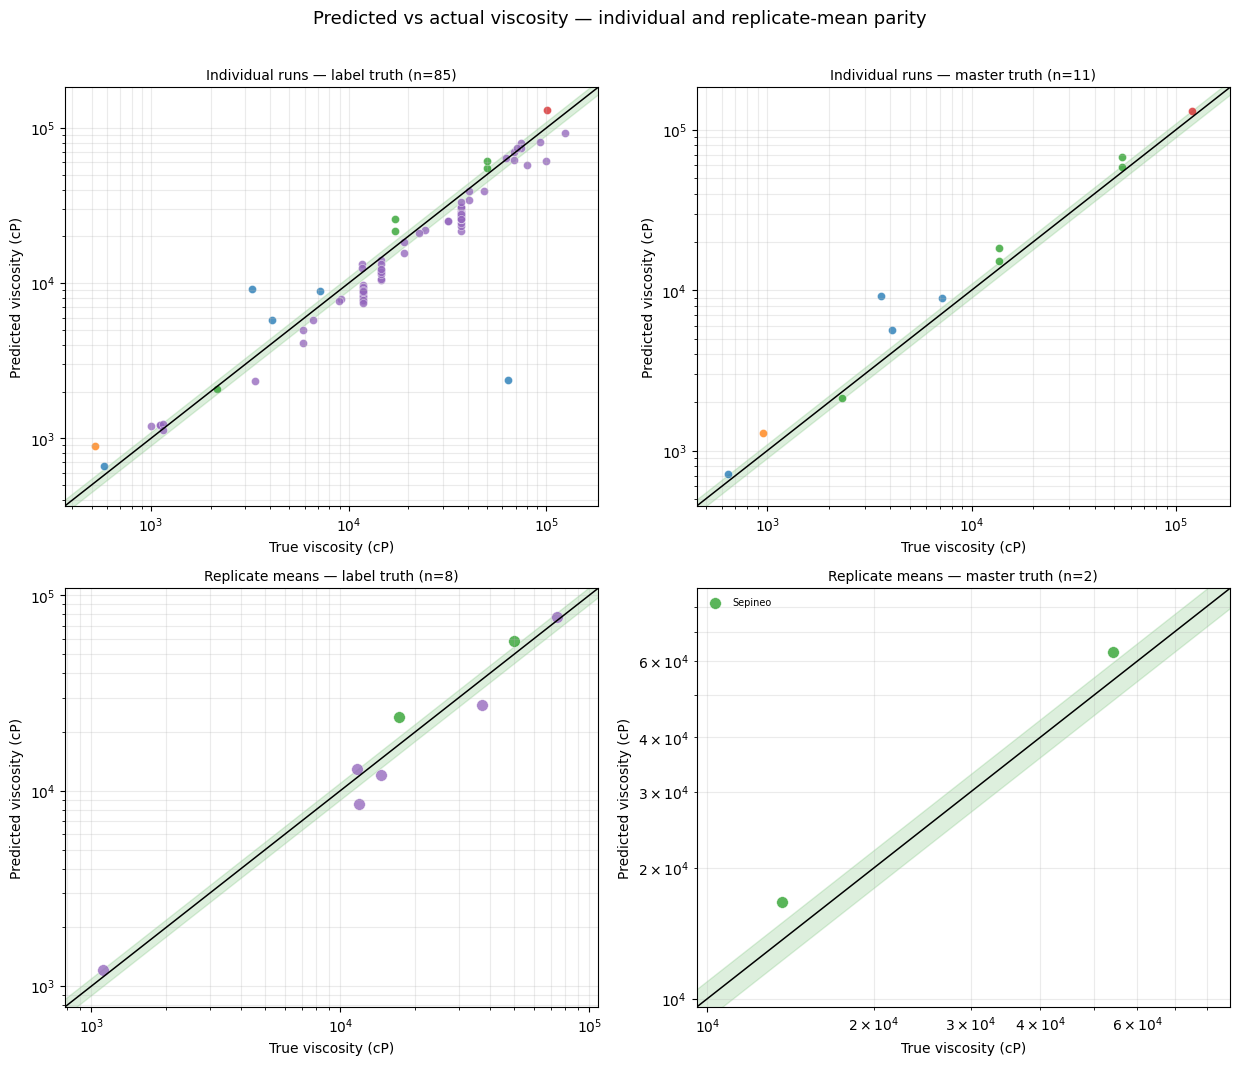

In [6]:
# §7 Parity plots (inline only — not written to disk)

def _parity_lims(df, x_col, y_col):
    vals = pd.concat([df[x_col], df[y_col]], ignore_index=True)
    vals = vals[vals > 0].dropna()
    if vals.empty:
        return None
    return [vals.min() * 0.7, vals.max() * 1.4]


def _draw_parity_panel(ax, df, x_col, y_col, title, *, marker_size=40, show_legend=False):
    if df is None or len(df) == 0:
        ax.set_title(title, fontsize=10)
        ax.text(0.5, 0.5, "No matched points", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    for fam, g in df.groupby("family"):
        ax.scatter(
            g[x_col], g[y_col], s=marker_size, alpha=0.78, label=fam,
            c=FAMILY_COLOR.get(fam, "#333"), edgecolors="white", linewidths=0.35,
        )
    lims = _parity_lims(df, x_col, y_col)
    if lims is not None:
        grid = np.logspace(np.log10(lims[0]), np.log10(lims[1]), 50)
        ax.fill_between(grid, 0.9 * grid, 1.1 * grid, color="#2ca02c", alpha=0.16, zorder=0)
        ax.plot(grid, grid, "k-", lw=1.1)
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("True viscosity (cP)")
    ax.set_ylabel("Predicted viscosity (cP)")
    ax.grid(True, which="both", alpha=0.25)
    if show_legend:
        ax.legend(frameon=False, fontsize=7, loc="best")


ind_label = run_acc_label.rename(columns={
    "mu_true_mean_cP": "mu_true_cP",
    "mu_pred_mean_cP": "mu_pred_cP",
})
ind_master = run_acc_master.rename(columns={
    "mu_true_mean_cP": "mu_true_cP",
    "mu_pred_mean_cP": "mu_pred_cP",
})

rep_label = replicate_means_label.rename(columns={
    "mu_true_mean_cP": "mu_true_cP",
    "mu_pred_mean_cP": "mu_pred_cP",
}) if len(replicate_means_label) else pd.DataFrame()
rep_master = replicate_means_master.rename(columns={
    "mu_true_mean_cP": "mu_true_cP",
    "mu_pred_mean_cP": "mu_pred_cP",
}) if len(replicate_means_master) else pd.DataFrame()

fig, axes = plt.subplots(2, 2, figsize=(12.5, 10.5), sharex=False, sharey=False)
_draw_parity_panel(
    axes[0, 0], ind_label, "mu_true_cP", "mu_pred_cP",
    f"Individual runs — label truth (n={len(ind_label)})", marker_size=34,
)
_draw_parity_panel(
    axes[0, 1], ind_master, "mu_true_cP", "mu_pred_cP",
    f"Individual runs — master truth (n={len(ind_master)})", marker_size=34,
)
_draw_parity_panel(
    axes[1, 0], rep_label, "mu_true_cP", "mu_pred_cP",
    f"Replicate means — label truth (n={len(rep_label)})", marker_size=70,
)
_draw_parity_panel(
    axes[1, 1], rep_master, "mu_true_cP", "mu_pred_cP",
    f"Replicate means — master truth (n={len(rep_master)})", marker_size=70, show_legend=True,
)
fig.suptitle("Predicted vs actual viscosity — individual and replicate-mean parity", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()


## §8 Shear graphs for non-Newtonian samples

For cells routed to mild / strong shear-thinning or shear-thickening: plot $\tau(\dot\gamma)$ and
$\eta(\dot\gamma)$ from pathway viscosities, overlay the stress power-law when available, and mark
Brookfield reference points when those exact-RPM master values exist.


Non-Newtonian cells to plot: 12


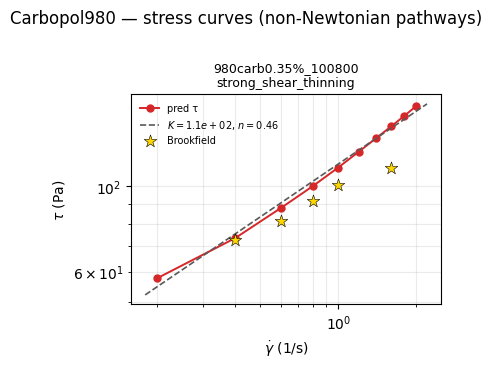

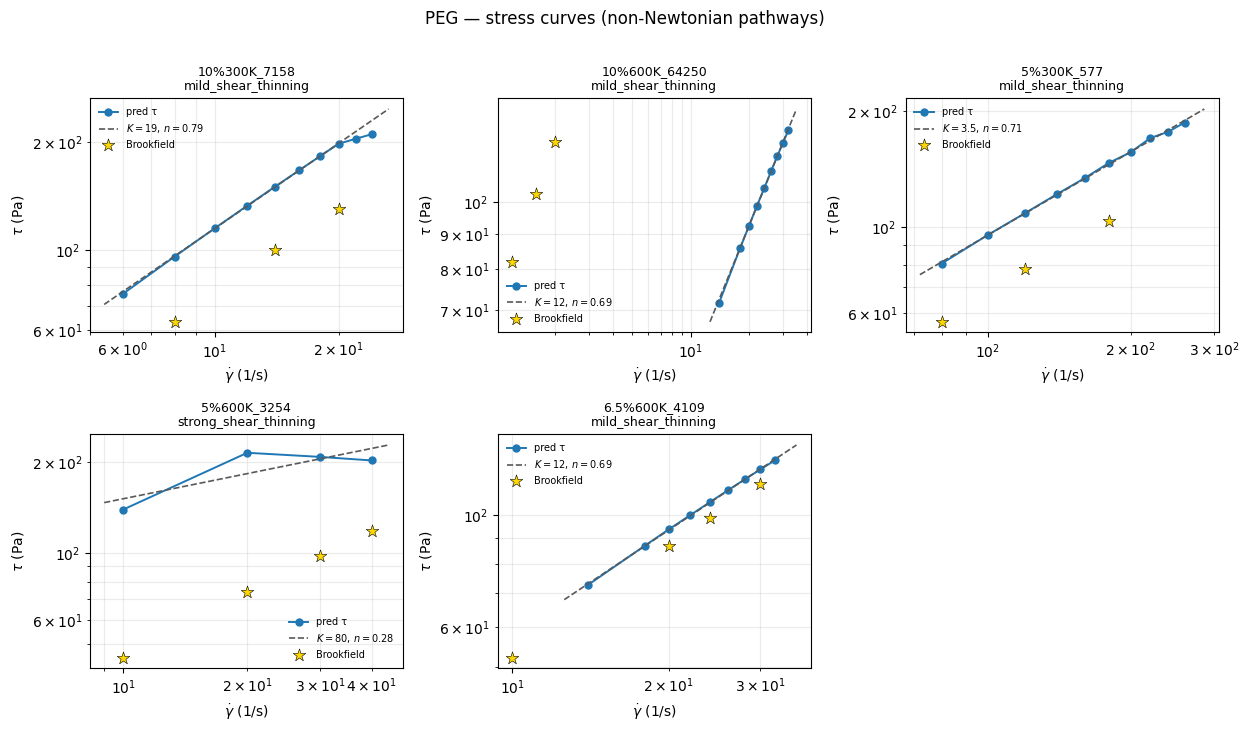

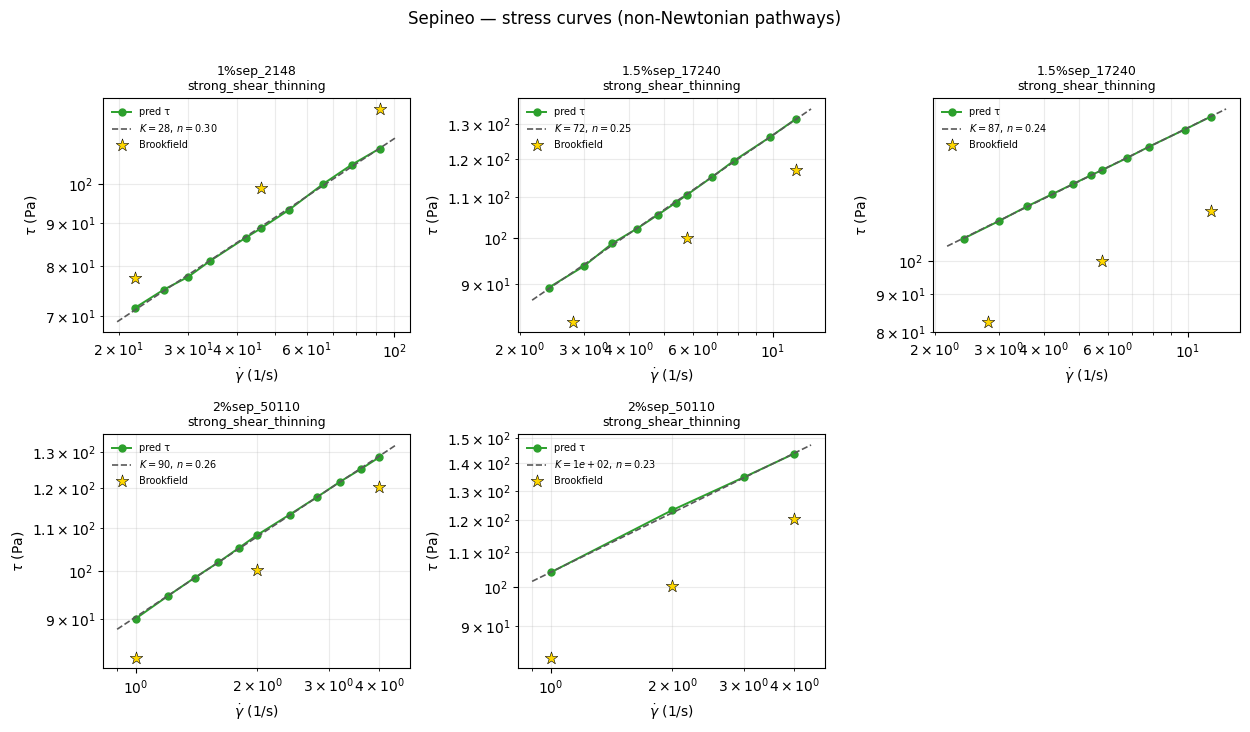

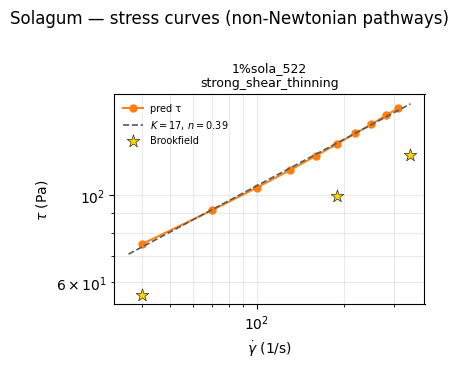

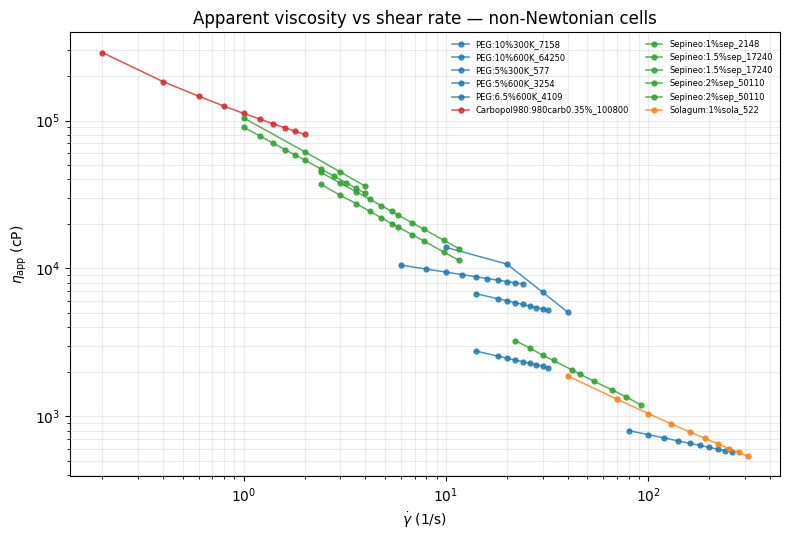

In [7]:
# §8 Non-Newtonian shear graphs (inline only — not written to disk)
nn = summaries[summaries["pathway"].isin(NON_NEWTONIAN) & summaries["success"].fillna(False)].copy()
print(f"Non-Newtonian cells to plot: {len(nn)}")

for fam, fam_nn in nn.groupby("family"):
    n = len(fam_nn)
    ncols = min(3, max(n, 1))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows), squeeze=False)
    for ax in axes.ravel()[n:]:
        ax.axis("off")

    for ax, (_, row) in zip(axes.ravel(), fam_nn.iterrows()):
        key = (row["family"], int(row["cell"]), row["label"])
        payload = cell_payloads[key]
        info = payload["info"]
        per_rpm = payload["per_rpm"]
        summary = payload["summary"]

        g_pts, tau_pts = [], []
        for rpm, fit in sorted(per_rpm.items()):
            if not fit.get("success"):
                continue
            mu_kcp = fit.get("viscosity_kcp")
            if mu_kcp is None:
                continue
            mu_cp = float(mu_kcp) * 1000.0
            g = float(shear_rate(rpm))
            tau = fit.get("tau_Pa_hit")
            if tau is None or not np.isfinite(tau):
                tau = (mu_cp * 1e-3) * g
            g_pts.append(g)
            tau_pts.append(float(tau))

        if len(g_pts) < 2:
            ax.set_title(f"{row['label']} (insuff.)", fontsize=9)
            continue

        g_arr = np.asarray(g_pts, float)
        tau_arr = np.asarray(tau_pts, float)
        ax.plot(g_arr, tau_arr, "o-", color=FAMILY_COLOR.get(fam, "#333"), ms=5, lw=1.4, label="pred τ")

        Ks, ns = summary.get("K_stress"), summary.get("n_stress")
        if Ks is not None and ns is not None and np.isfinite(Ks) and np.isfinite(ns):
            gg = np.logspace(np.log10(g_arr.min() * 0.9), np.log10(g_arr.max() * 1.1), 40)
            ax.plot(gg, float(Ks) * gg ** float(ns), "--", color="0.35", lw=1.2,
                    label=fr"$K={float(Ks):.2g},\,n={float(ns):.2f}$")

        saw_bf = False
        for rpm_ref, mu_ref in master_points_for_sample(info["family"], info["conc"], info["mw"]):
            g_ref = float(shear_rate(rpm_ref))
            tau_ref = (mu_ref * 1e-3) * g_ref
            ax.scatter([g_ref], [tau_ref], marker="*", s=90, c="gold", edgecolors="k",
                       linewidths=0.4, zorder=5, label="Brookfield" if not saw_bf else None)
            saw_bf = True

        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel(r"$\dot\gamma$ (1/s)")
        ax.set_ylabel(r"$\tau$ (Pa)")
        ax.set_title(f"{row['label']}\n{row['pathway']}", fontsize=9)
        handles, labels = ax.get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        ax.legend(uniq.values(), uniq.keys(), fontsize=7, frameon=False)
        ax.grid(True, which="both", alpha=0.25)

    fig.suptitle(f"{fam} — stress curves (non-Newtonian pathways)", fontsize=12, y=1.01)
    fig.tight_layout()
    plt.show()

if len(nn):
    fig, ax = plt.subplots(figsize=(8, 5.5))
    for _, row in nn.iterrows():
        key = (row["family"], int(row["cell"]), row["label"])
        per_rpm = cell_payloads[key]["per_rpm"]
        g_pts, eta_pts = [], []
        for rpm, fit in sorted(per_rpm.items()):
            if not fit.get("success") or fit.get("viscosity_kcp") is None:
                continue
            g_pts.append(float(shear_rate(rpm)))
            eta_pts.append(float(fit["viscosity_kcp"]) * 1000.0)
        if len(g_pts) >= 2:
            ax.plot(g_pts, eta_pts, "o-", ms=3.5, lw=1.1, alpha=0.8,
                    color=FAMILY_COLOR.get(row["family"], "#333"),
                    label=f"{row['family']}:{row['label']}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$\dot\gamma$ (1/s)")
    ax.set_ylabel(r"$\eta_{\mathrm{app}}$ (cP)")
    ax.set_title("Apparent viscosity vs shear rate — non-Newtonian cells")
    ax.legend(fontsize=6, frameon=False, ncol=2, loc="best")
    ax.grid(True, which="both", alpha=0.25)
    fig.tight_layout()
    plt.show()


## §9 Summary


In [8]:
# §9 Summary
print("=" * 60)
print("THREE-PATHWAY CHARACTERIZATION SUMMARY")
print("=" * 60)
print(f"Runs (label, cell): {len(summaries)}   Per-RPM predictions: {len(parity)}")
print(f"Matched truth pairs: {len(with_truth)}")
print("\nPathway distribution:")
print(summaries["pathway"].fillna("None").value_counts().to_string())
sil = summaries[summaries["family"] == "Silicone"]
if len(sil):
    print(f"\nSilicone runs: {len(sil)}  all Newtonian: {(sil['pathway'] == 'newtonian').all()}")
if len(with_truth):
    print("\nMedian |%err| by family:")
    print(with_truth.groupby("family")["abs_pct_err"].agg(["median", "mean", "count"]).to_string())
    print("\nMedian |%err| by pathway:")
    print(with_truth.groupby("pathway")["abs_pct_err"].agg(["median", "mean", "count"]).to_string())
if len(replicate_means):
    print(f"\nReplicate samples (≥2 runs): {len(replicate_means)}")
    print("Mean-of-replicates |%err| by family:")
    print(
        replicate_means.groupby("family")["abs_pct_err_mean"]
        .agg(["median", "mean", "count"])
        .to_string()
    )
print("\nArtifacts:")
for name in [
    "parity_by_rpm.csv",
    "cell_summaries.csv",
    "run_accuracy.csv",
    "replicate_individual.csv",
    "replicate_means.csv",
]:
    print(" ", OUT_DIR / name)
print(" Figures are displayed inline in this notebook (not saved to disk).")


THREE-PATHWAY CHARACTERIZATION SUMMARY
Runs (label, cell): 92   Per-RPM predictions: 217
Matched truth pairs: 182

Pathway distribution:
pathway
newtonian                75
strong_shear_thinning     8
None                      5
mild_shear_thinning       4

Silicone runs: 74  all Newtonian: True

Median |%err| by family:
                median       mean  count
family                                  
Carbopol980  18.019753  40.265096     10
PEG          36.932100  55.872150     42
Sepineo      28.276017  38.805972     47
Silicone     20.892537  19.823872     73
Solagum      43.296757  71.987674     10

Median |%err| by pathway:
                          median       mean  count
pathway                                           
mild_shear_thinning    32.169743  42.703519     38
newtonian              20.892537  19.823872     73
strong_shear_thinning  29.553663  51.694436     71

Replicate samples (≥2 runs): 8
Mean-of-replicates |%err| by family:
             median       mean  count
f